In [6]:
import ehr_utils
#使用什么数据  可选 mean drop  bayesian
data_type = 'mean'
models_list = ehr_utils.get_all_trained_models(f'trained_models/{data_type}')
file_path = f'data_cleaned/ver-noelectrolyte-logtransform_{data_type}.csv'
X_train, X_test, Y_train, Y_test = ehr_utils.get_train_test(file_path)

检测到 10 个模型：['trained_models/mean/AdaBoost_0.67.pkl', 'trained_models/mean/DecisionTree_0.65.pkl', 'trained_models/mean/GaussianNB_0.62.pkl', 'trained_models/mean/GradientBoosting_0.68.pkl', 'trained_models/mean/LightGBM_0.69.pkl', 'trained_models/mean/LinearDiscriminantAnalysis_0.67.pkl', 'trained_models/mean/LogisticRegression_0.64.pkl', 'trained_models/mean/MLPClassifier_0.68.pkl', 'trained_models/mean/RandomForest_0.64.pkl', 'trained_models/mean/XGBoost_0.69.pkl']


In [4]:
from matplotlib import pyplot as plt
import pandas as pd
import os
# plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.family"]  = ['monospace'] # 指定默认字体
plt.rcParams["font.monospace"].insert(0,'Ubuntu Sans Mono')# 指定默认字体

plt.rcParams['axes.unicode_minus'] = False # 解决保存图像是负号'-'显示为方块的问题
from sklearn.metrics import auc, average_precision_score, precision_recall_curve, roc_curve


def plot_all_models_roc_pr(trained_models, X_test, Y_test):
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))
    # 颜色表
    C = ['#f98e62', '#d6eef4', '#f0c184', '#f6ebb1', '#929fc9', '#f8fbcb', '#ef8c67', '#8074ca', '#a5d954', '#b44763']
    # 为了输出对齐,出此下策， 后期再想解决办法
    # names = ["ADB   ", "DT     ", "GNB   ", "GB     ", "LGBM ", "LDA    ", "LR      ", "MLP    ", "RF      ", "XGB   "]
    names = ["ADB", "DT", "GNB", "GB", "LGBM", "LDA", "LR", "MLP", "RF", "XGB"]
    # 设置固定宽度
    width = 4
    # 使用 ljust() 对齐
    names = [name.ljust(width) for name in names]
    # 遍历每个模型，计算AUC和PRC，并绘制曲线
    for i, model in enumerate(trained_models[:-1]):
        # 预测概率
        y_pred_prob = model.predict_proba(X_test)[:, 1]

        # 计算ROC曲线
        fpr, tpr, _ = roc_curve(Y_test, y_pred_prob)
        auc_score = auc(fpr, tpr)
        # 绘制AUC曲线
        ax[0].plot(fpr, tpr, label=f'{names[i]}({auc_score:.2f})', color=C[i], alpha=0.7, linewidth=1)

        # 计算PRC曲线
        precision, recall, _ = precision_recall_curve(Y_test, y_pred_prob)
        prc_score = average_precision_score(Y_test, y_pred_prob)
        # 绘制PRC曲线
        name_width = 5
        ax[1].plot(recall, precision, label=f'{names[i]}({prc_score:.2f})', color=C[i], alpha=0.7, linewidth=1)
    y_pred_prob = trained_models[-1].predict_proba(X_test)[:, 1]
    # 计算ROC曲线
    fpr, tpr, _ = roc_curve(Y_test, y_pred_prob)
    auc_score = auc(fpr, tpr)
    # 绘制AUC曲线
    ax[0].plot(fpr, tpr, label=f'{names[-1]}({auc_score:.2f})', color=C[-1], alpha=0.9, linewidth=2)

    # 计算PRC曲线
    precision, recall, _ = precision_recall_curve(Y_test, y_pred_prob)
    prc_score = average_precision_score(Y_test, y_pred_prob)
    # 绘制PRC曲线
    ax[1].plot(recall, precision, label=f'{names[-1]}({prc_score:.2f})', color=C[-1], alpha=0.9, linewidth=2)
    # 显示图表
    ax[0].set_ylim(0, 1)
    ax[0].set_xlim(0, 1)
    ax[1].set_ylim(0, 1)
    ax[1].set_xlim(0, 1)
    ax[0].set_title('ROC Curves')
    ax[0].set_xlabel('False Positive Rate')
    ax[0].set_ylabel('True Positive Rate')
    ax[0].legend(loc='lower right')
    ax[1].set_title('PRC Curves')
    ax[1].set_xlabel('Recall')
    ax[1].set_ylabel('Precision')
    ax[1].legend(loc='best')
    plt.tight_layout()
    fig.savefig('results_fig/roc_pr_curves_all.png')
    plt.show()
def eval_all_models_to_excel(trained_models, X_test, Y_test, data_type):
    metrics=[]
    names = ["ADB", "DT", "GNB", "GB", "LGBM", "LDA", "LR", "MLP", "RF", "XGB"]
    for model in trained_models:
        Y_prob,Y_pred=ehr_utils.get_prediction_results(model, X_test)
        model_metrics = ehr_utils.eval_model(Y_test, Y_prob, Y_pred)
        metrics.append(model_metrics)
    # 创建一个 DataFrame
    df = pd.DataFrame(metrics, index=names, columns=['AUC', 'AUC_CI_Low', 'AUC_CI_High', 'Accuracy', 'Sensitivity', 'Specificity', 'PPV', 'NPV', 'F1'])
    os.makedirs('result_tables', exist_ok=True)
    # 保存到 Excel 文件，指定目标工作表名称
    with pd.ExcelWriter('result_tables/model_metrics.xlsx', engine='openpyxl', mode='a', if_sheet_exists='replace') as writer:
        df.to_excel(writer, sheet_name=data_type, index=True)

FileNotFoundError: [Errno 2] No such file or directory: '/home/mclab/ydl/ehr0528/results/roc_pr_curves_all.png'

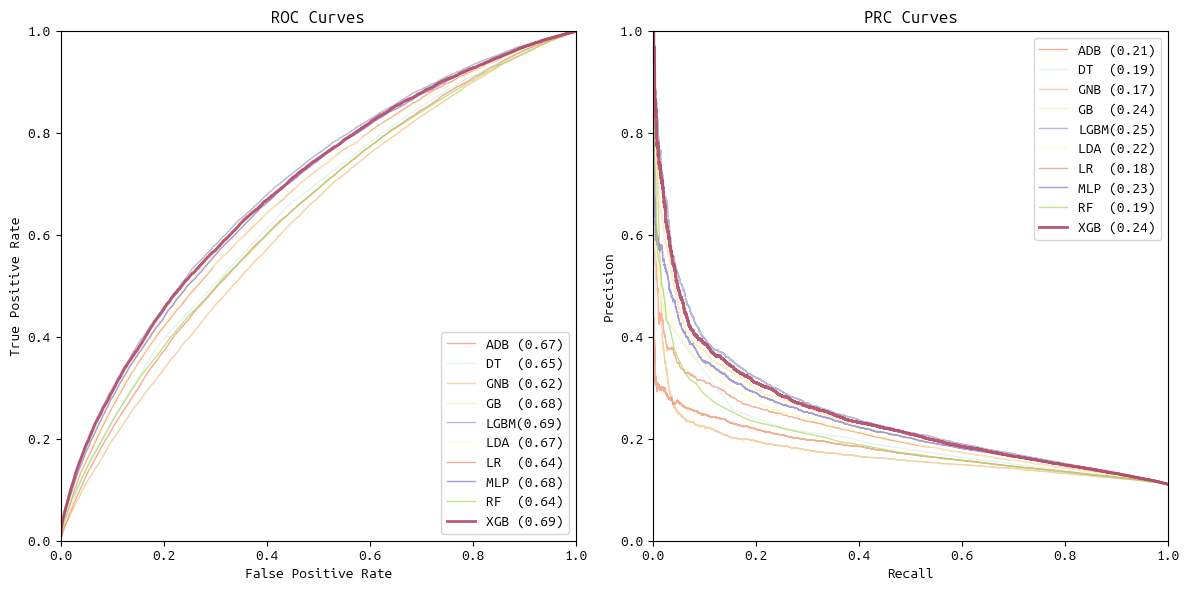

In [4]:
plot_all_models_roc_pr(models_list, X_test, Y_test)


In [7]:
##评估trained_models_{控制填充方法}下的所有模型，将其保存到xlsx中的一个sheet中

eval_all_models_to_excel(models_list, X_test, Y_test, data_type)

/home/mclab/miniconda3/envs/ydl/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
